# Phần 1 - Bài toán Hồi quy (Regression)


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Định nghĩa đường dẫn 
---

In [21]:
# Đường dẫn tương đối của file dữ liệu
path = "../../data/"


In [4]:
# Kiểm tra đường dẫn có tồn tại không 
if not os.path.exists(path):
    print(f"Đường dẫn {path} không tồn tại.")
else:
    print(f"Đường dẫn {path} tồn tại.")

Đường dẫn ../../data/ tồn tại.


## Đọc dữ liệu từ các file csv 
- **olist_orders_dataset.csv** : `order_id, customer_id, order_purchase_timestamp, order_delivered_customer_date`

- **olist_order_items_dataset.csv**

- **olist_customers_dataset.csv**

- **olist_selllers_dataset.csv**

- **olist_products_dataset.csv**

- **product_category_name_transalation**

In [18]:
# 1. Bảng gốc olist_orders_dataset
if os.path.exists(os.path.join(path, "olist_orders_dataset.csv")):
    orders_df = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
    print("Bảng olist_orders_dataset đã được tải thành công.")
else:    
    print("Bảng olist_orders_dataset không tồn tại trong đường dẫn.")


# 2. Bảng gốc olist_order_items_dataset
if os.path.exists(os.path.join(path, "olist_order_items_dataset.csv")): 
    order_items_df = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
    print("Bảng olist_order_items_dataset đã được tải thành công.")
else:
    print("Bảng olist_order_items_dataset không tồn tại trong đường dẫn.")

# 3. Bảng gốc olist_customers_dataset
if os.path.exists(os.path.join(path, "olist_customers_dataset.csv")):
    customers_df = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
    print("Bảng olist_customers_dataset đã được tải thành công.")
else:
    print("Bảng olist_customers_dataset không tồn tại trong đường dẫn.")

# 4. Bảng gốc olist_sellers_dataset
if os.path.exists(os.path.join(path, "olist_sellers_dataset.csv")):
    sellers_df = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
    print("Bảng olist_sellers_dataset đã được tải thành công.")
else:
    print("Bảng olist_sellers_dataset không tồn tại trong đường dẫn.")


# 5. Bảng gốc olist_products_dataset
if os.path.exists(os.path.join(path, "olist_products_dataset.csv")):
    products_df = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
    print("Bảng olist_products_dataset đã được tải thành công.")
else:
    print("Bảng olist_products_dataset không tồn tại trong đường dẫn.")

# 6. Bảng gốc olist_category_name_translation.csv
if os.path.exists(os.path.join(path, "product_category_name_translation.csv")):
    category_translation_df = pd.read_csv(os.path.join(path, "product_category_name_translation.csv"))
    print("Bảng olist_category_name_translation đã được tải thành công.")
else:
    print("Bảng olist_category_name_translation không tồn tại trong đường dẫn.")

print("\nThông tin về các bảng dữ liệu:")
print("\n1. Bảng olist_orders_dataset:")
print(orders_df.shape)
print("\n2. Bảng olist_order_items_dataset:")
print(order_items_df.shape)
print("\n3. Bảng olist_customers_dataset:")
print(customers_df.shape)
print("\n4. Bảng olist_sellers_dataset:")
print(sellers_df.shape)
print("\n5. Bảng olist_products_dataset:")
print(products_df.shape) 
print("\n6. Bảng olist_category_name_translation:")
print(category_translation_df.shape)



Bảng olist_orders_dataset đã được tải thành công.
Bảng olist_order_items_dataset đã được tải thành công.
Bảng olist_customers_dataset đã được tải thành công.
Bảng olist_sellers_dataset đã được tải thành công.
Bảng olist_products_dataset đã được tải thành công.
Bảng olist_category_name_translation đã được tải thành công.

Thông tin về các bảng dữ liệu:

1. Bảng olist_orders_dataset:
(99441, 8)

2. Bảng olist_order_items_dataset:
(112650, 7)

3. Bảng olist_customers_dataset:
(99441, 5)

4. Bảng olist_sellers_dataset:
(3095, 4)

5. Bảng olist_products_dataset:
(32951, 9)

6. Bảng olist_category_name_translation:
(71, 2)


## Gộp dữ liệu lại thành một file data.csv 

In [23]:
data = orders_df.merge(order_items_df, on='order_id' , how='inner') \
    .merge(customers_df, on='customer_id' , how='inner') \
    .merge(sellers_df, on='seller_id' , how='inner') \
    .merge(products_df, on='product_id' , how='inner') \
    .merge(category_translation_df, on='product_category_name' , how='inner')
print("\nKết quả sau khi merge các bảng dữ liệu:")
print(data.shape)
data.head()

# Ghi ra file dữ liệu đã được merge vào đường dẫn tương đối
output_path = os.path.join(path, "raw_data.csv")
data.to_csv(output_path, index=False)
print(f"Dữ liệu đã được ghi ra file {output_path} thành công.")



Kết quả sau khi merge các bảng dữ liệu:
(111023, 30)
Dữ liệu đã được ghi ra file ../../data/raw_data.csv thành công.


## 1. Phân tích và tiền xử lý
### a. Phân tích và khám phá (EDA)
- Thông kê mô tả

In [5]:
data.describe()

NameError: name 'data' is not defined

- Loại bỏ những cột có quá nhiều giá trị null (>50%)

In [ ]:
missing_value = data.isnull().sum()
print('Số lượng giá trị thiếu trong mỗi cột: ')
print(missing_value[missing_value > 0])
data = drop_high_missing_columns(data,0.5)

Số lượng giá trị thiếu trong mỗi cột: 
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
dtype: int64
Đã loại bỏ các cột sau (> 50.0% missing):
 - House direction: 70.26%
 - Balcony direction: 82.65%


- Phân bố của biến mục tiêu

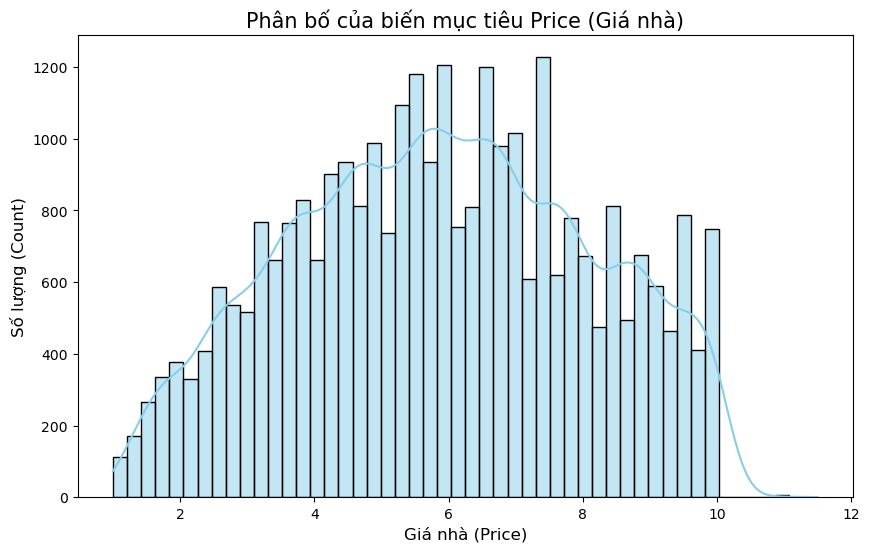

In [ ]:
# Thiết lập kích thước
plt.figure(figsize=(10, 6))

# Vẽ Histogram
sns.histplot(data['Price'], kde=True, color='skyblue')

# Thêm tiêu đề và nhãn theo quy định đồ án 
plt.title('Phân bố của biến mục tiêu Price (Giá nhà)', fontsize=15)
plt.xlabel('Giá nhà (Price)', fontsize=12)
plt.ylabel('Số lượng (Count)', fontsize=12)

# Hiển thị
plt.show()

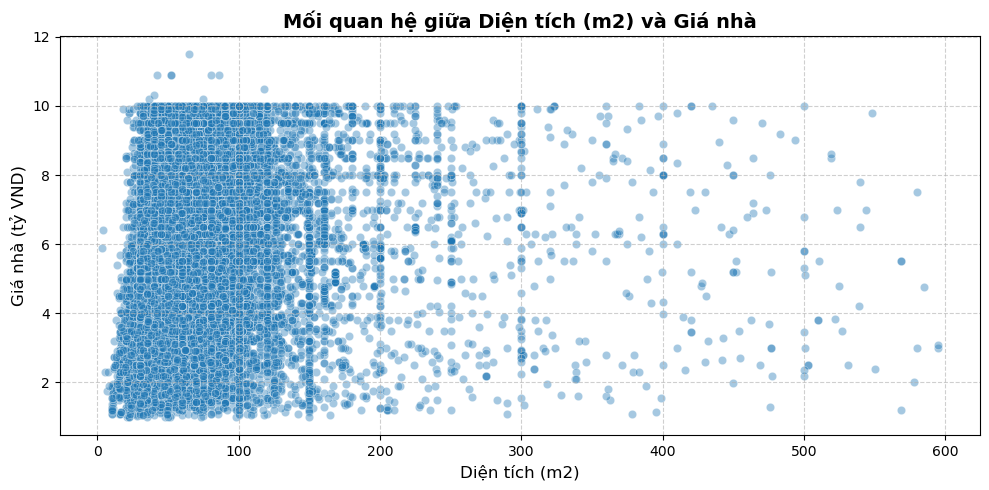

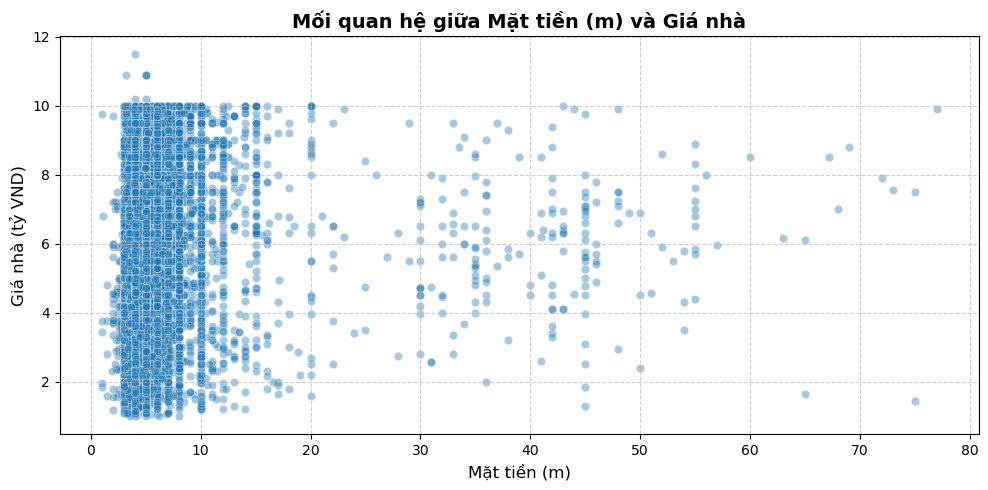

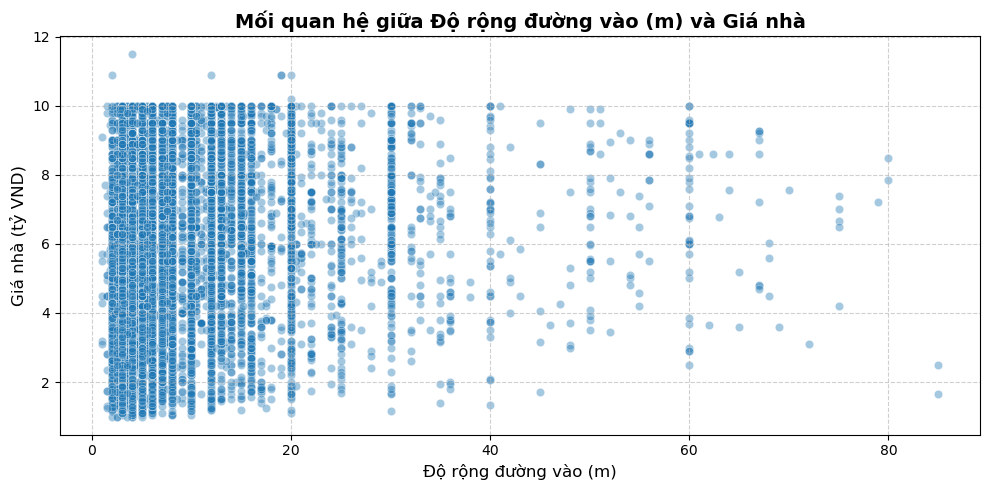

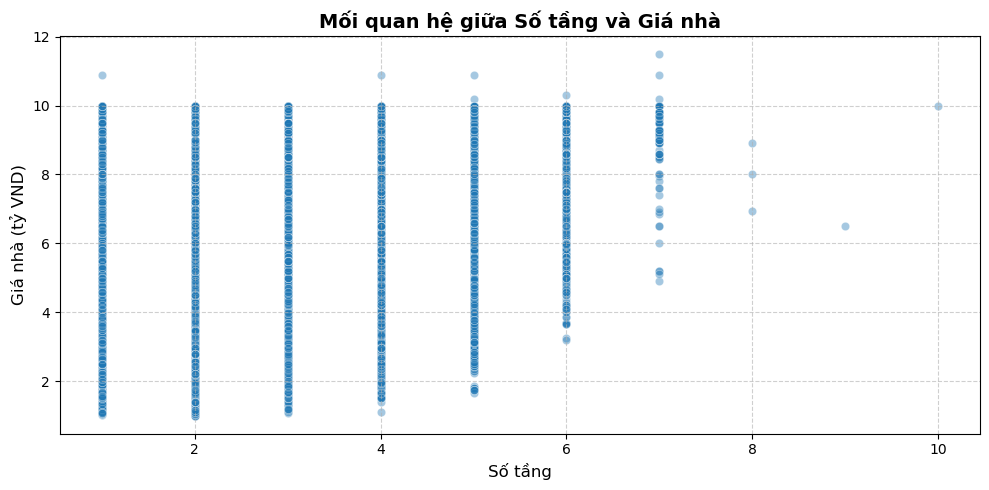

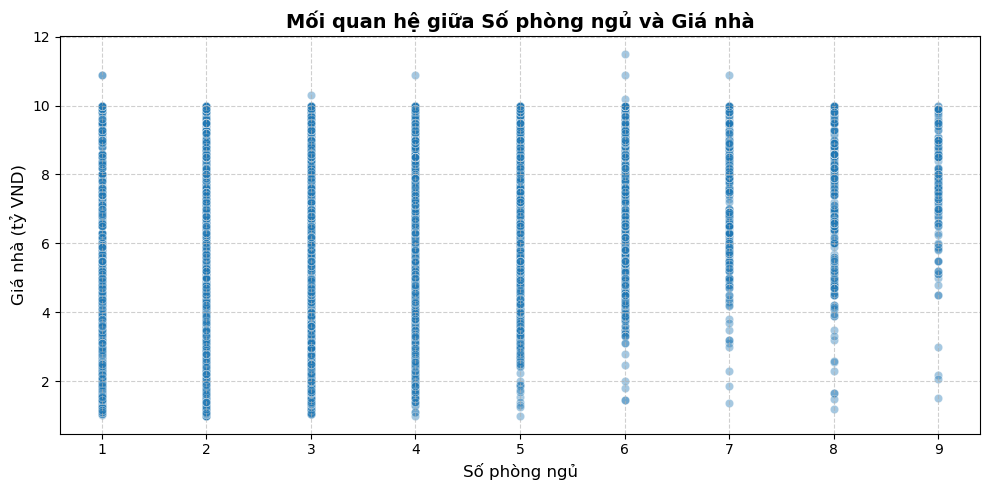

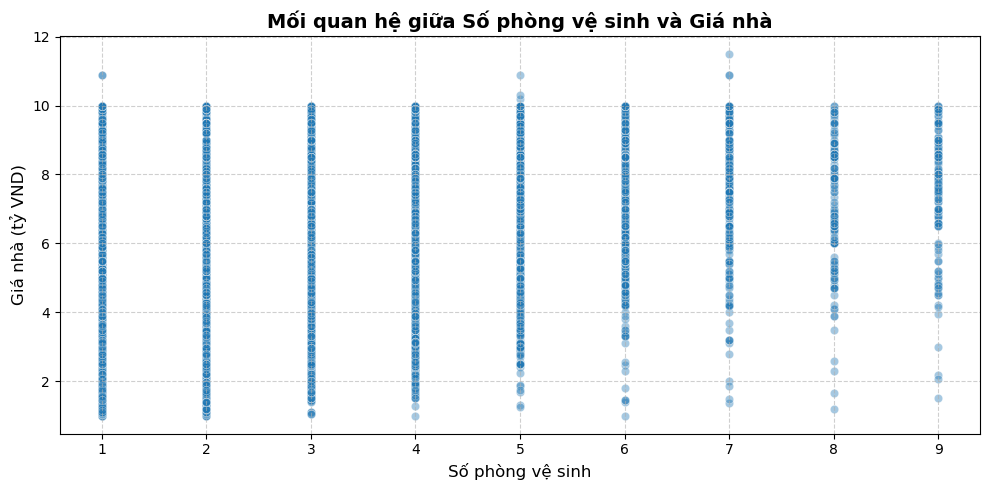

In [ ]:
# 1. Tạo từ điển để dịch tên các đặc trưng (tùy chỉnh theo cột trong file CSV của bạn)
name_mapping = {
    'Area': 'Diện tích (m2)',
    'Floors': 'Số tầng',
    'Bedrooms': 'Số phòng ngủ',
    'Bathrooms': 'Số phòng vệ sinh',
    'Frontage': 'Mặt tiền (m)',
    'Access Road': 'Độ rộng đường vào (m)',
    'Price': 'Giá nhà'
}

# 2. Lấy danh sách các đặc trưng số
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
numerical_features = numerical_features.drop('Price', errors='ignore')

# 3. Vẽ biểu đồ scatter cho từng đặc trưng
for feature in numerical_features:
    # Lấy tên tiếng Việt từ mapping, nếu không có thì dùng tên gốc
    feature_vn = name_mapping.get(feature, feature)
    price_vn = name_mapping.get('Price', 'Giá')
    
    plt.figure(figsize=(10, 5))
    
    # Vẽ scatter plot với màu sắc chuyên nghiệp hơn
    sns.scatterplot(data=data, x=feature, y='Price', alpha=0.4)
    
    # Việt hóa các tiêu đề và nhãn theo yêu cầu mục 2.2.2 
    plt.title(f'Mối quan hệ giữa {feature_vn} và {price_vn}', fontsize=14, fontweight='bold')
    plt.xlabel(feature_vn, fontsize=12)
    plt.ylabel(f'{price_vn} (tỷ VND)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

- Xử lý outlier value

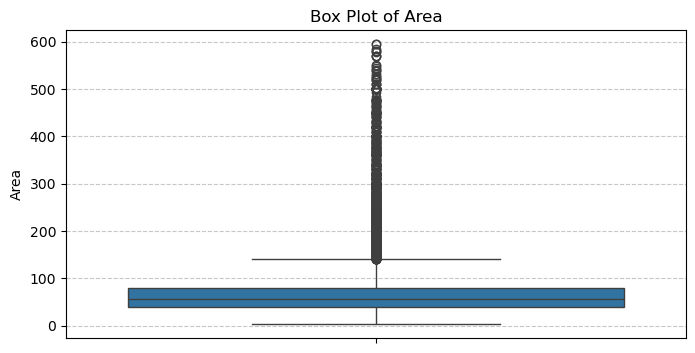

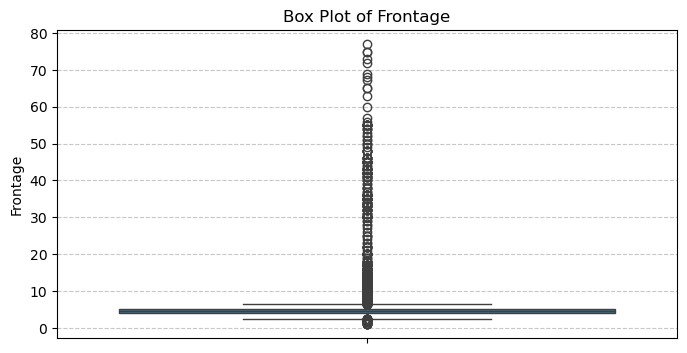

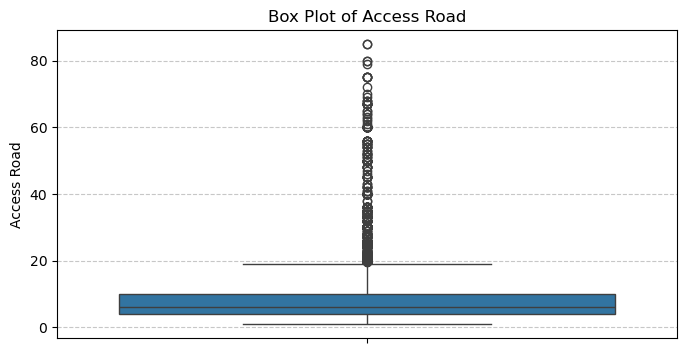

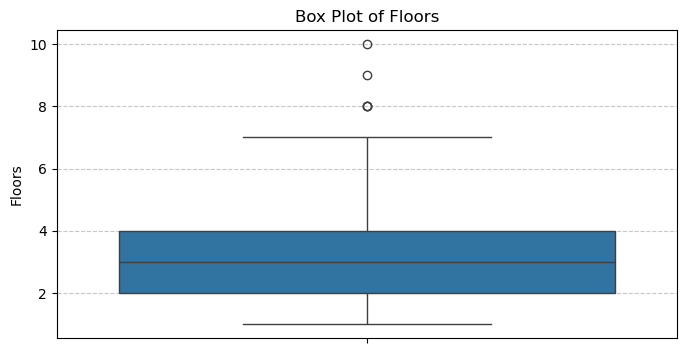

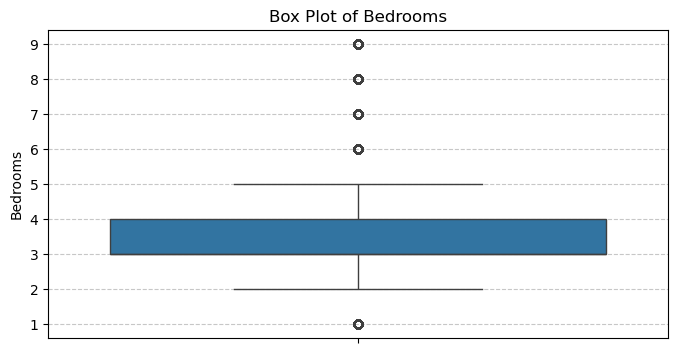

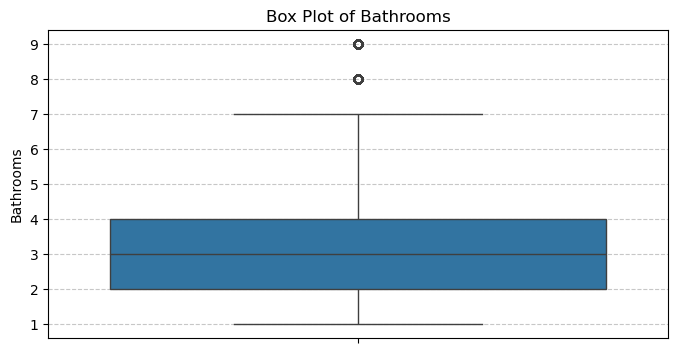

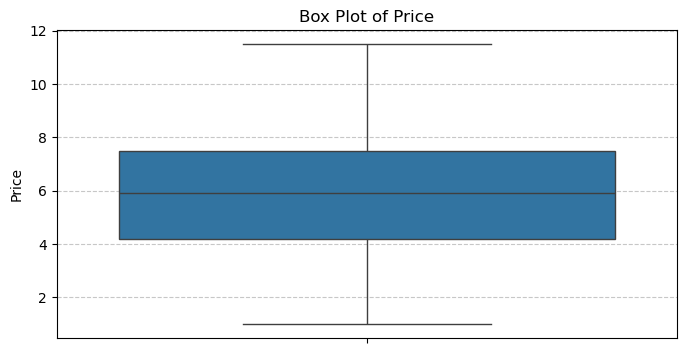

In [ ]:
# Biểu đồ Boxplot để xem phân phối của các biến số
numerical_cols = data.select_dtypes(include=['number']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()